## Exploring canada's energy future

url : https://apps2.cer-rec.gc.ca/energy-future/?page=by-sector&mainSelection=energyDemand&yearId=2026&sector=ALL&unit=petajoules&view=&baseYear=&compareYear=&noCompare=&priceSource=&scenarios=Current%20Measures&provinces=ALL&provinceOrder=YT,SK,QC,PE,ON,NU,NT,NS,NL,NB,MB,BC,AB&sources=BIO,COAL,ELECTRICITY,GAS,HYDROGEN,OIL&sourceOrder=BIO,COAL,ELECTRICITY,GAS,HYDROGEN,OIL



https://www.cer-rec.gc.ca/open/energy/energyfutures2026/energy-demand-2026.csv

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import requests as req
import io
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import streamlit
from ydata_profiling import ProfileReport

/var/folders/jj/z6z8sj0x5kn824vb1cnls1z00000gn/T/ipykernel_72030/2128372059.py:10: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
# This is the direct link to the 'Electricity demand 2026' CSV from the Open Gov portal
url = "https://www.cer-rec.gc.ca/open/energy/energyfutures2026/end-use-demand-2026.csv"

# Load directly into your project
df = pd.read_csv(url)

df.head()

,Scenario,Region,Variable,Year,Value,Sector
0,Canada Net-zero,Alberta,Aviation Fuel,2005,32.8145,Transportation
1,Canada Net-zero,Alberta,Aviation Fuel,2006,33.7407,Transportation
2,Canada Net-zero,Alberta,Aviation Fuel,2007,36.9111,Transportation
3,Canada Net-zero,Alberta,Aviation Fuel,2008,35.4645,Transportation
4,Canada Net-zero,Alberta,Aviation Fuel,2009,32.1618,Transportation


In [7]:
df.describe(include= 'all')

,Scenario,Region,Variable,Year,Value,Sector
count,100464,100464,100464,100464.000000,100464.000000,100464
unique,4,14,14,NaN,NaN,5
top,Canada Net-zero,Alberta,Electricity,NaN,NaN,Transportation
freq,25116,7176,12880,NaN,NaN,28336
mean,NaN,NaN,NaN,2027.500000,167.465296,NaN
std,NaN,NaN,NaN,13.275984,711.839982,NaN
min,NaN,NaN,NaN,2005.000000,0.000000,NaN
25%,NaN,NaN,NaN,2016.000000,0.000000,NaN
50%,NaN,NaN,NaN,2027.500000,2.955700,NaN
75%,NaN,NaN,NaN,2039.000000,52.014400,NaN


In [8]:
df.Scenario.unique()

array(['Canada Net-zero', 'Current Measures', 'Higher Scenario',
       'Lower Scenario'], dtype=object)

In [52]:
df.Sector.unique()

array(['Transportation', 'Commercial', 'Industrial', 'Residential',
       'Total End-Use'], dtype=object)

In [9]:
df.Variable.unique()

array(['Aviation Fuel', 'Biofuels', 'Biofuels & Emerging Energy',
       'Diesel', 'Electricity', 'Heavy Fuel Oil', 'Hydrogen', 'LPG',
       'Lubricants', 'Motor Gasoline', 'Natural Gas', 'Other', 'RPP',
       'Total End-Use'], dtype=object)

In [14]:
print(df.Year.min())
print(df.Year.max())

2005
2050


In [15]:
df.Sector.unique()


array(['Transportation', 'Commercial', 'Industrial', 'Residential',
       'Total End-Use'], dtype=object)

In [16]:
df.Region.unique()

array(['Alberta', 'British Columbia', 'Canada', 'Manitoba',
       'New Brunswick', 'Newfoundland and Labrador',
       'Northwest Territories', 'Nova Scotia', 'Nunavut', 'Ontario',
       'Prince Edward Island', 'Quebec', 'Saskatchewan', 'Yukon'],
      dtype=object)

In [23]:
df_Canada = df[df['Region'] =='Canada'].pivot_table(
    index ='Year',
    columns = 'Scenario',
    values = 'Value'
).sort_index()

In [24]:
df_Canada.head()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
Year,,,,
2005,1077.462338,1077.462338,1077.462338,1077.462338
2006,1072.510195,1072.510195,1072.510195,1072.510195
2007,1110.799990,1110.799990,1110.799990,1110.799990
2008,1091.056646,1091.056646,1091.056646,1091.056646
2009,1055.524338,1055.524338,1055.524338,1055.524338


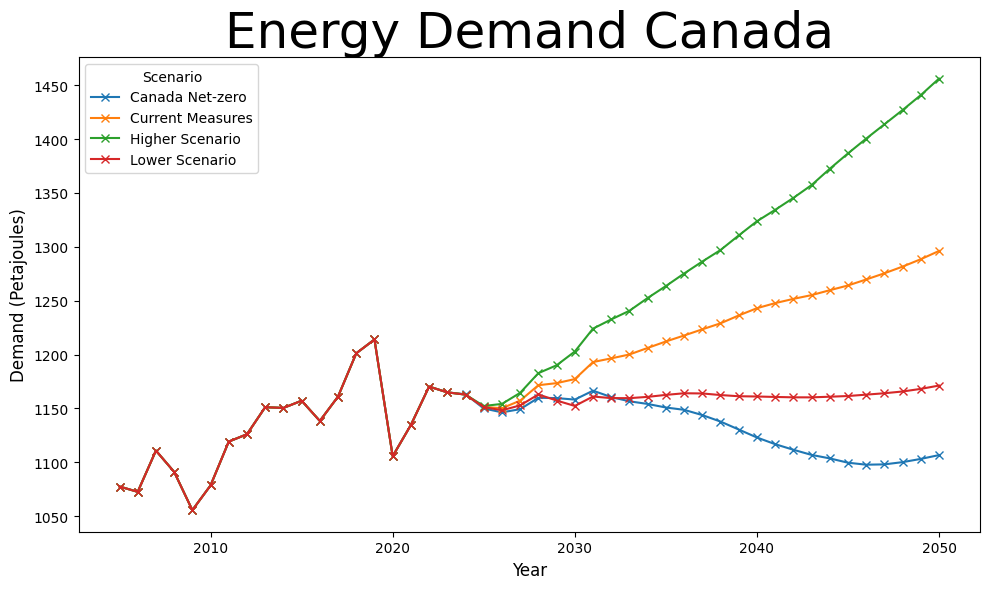

In [36]:
ax = df_Canada.plot(kind= 'line', marker = 'x', figsize = (10,6))
plt.title('Energy Demand Canada', fontsize = 36)
plt.xlabel('Year', fontsize =12)
plt.ylabel ('Demand (Petajoules)', fontsize =12)
plt.tight_layout()
plt.show()

In [39]:
df_Ontario = df[df['Region'] == 'Ontario'].pivot_table(
    index ='Year',
    columns = 'Scenario',
    values = 'Value'
).sort_index()

In [40]:
df_Ontario.head()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
Year,,,,
2005,313.059487,313.059487,313.059487,313.059487
2006,306.942738,306.942738,306.942738,306.942738
2007,312.281108,312.281108,312.281108,312.281108
2008,311.218964,311.218964,311.218964,311.218964
2009,286.204492,286.204492,286.204492,286.204492


In [51]:
df_Ontario.describe()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
count,46.000000,46.000000,46.000000,46.000000
mean,285.033066,300.968762,309.924506,294.612480
std,22.526767,11.623875,19.035495,12.828721
min,248.957067,279.201487,279.201487,279.201487
25%,266.807531,289.899726,294.811810,284.819990
50%,284.552015,300.060005,308.337574,287.119703
75%,306.783728,312.014633,318.626928,306.783728
max,321.654769,321.654769,359.337569,321.654769


In [60]:
df_Ontario.shape

(46, 4)

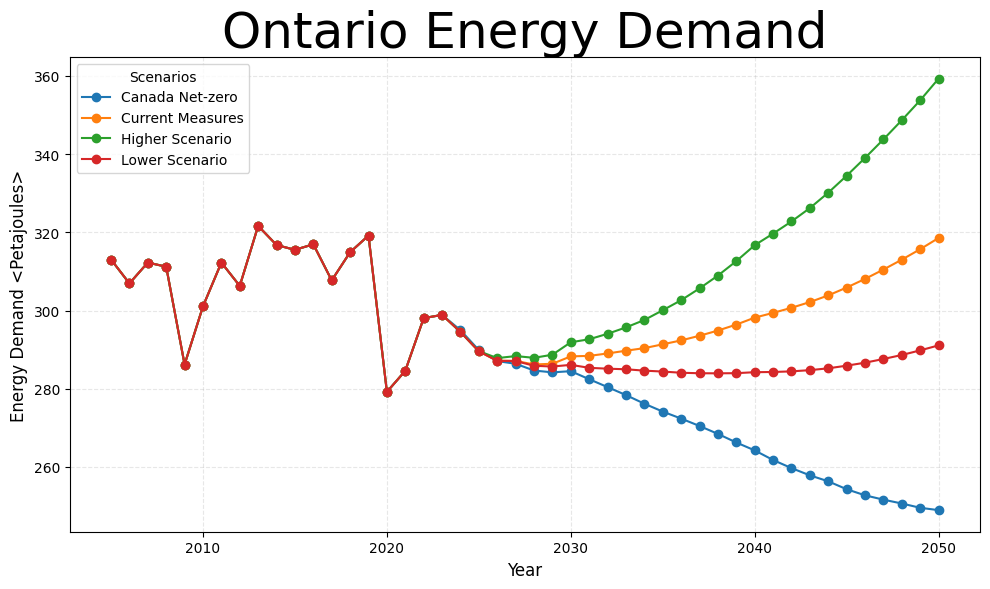

In [58]:
ax = df_Ontario.plot(kind='line', marker ='o' ,figsize=(10,6))
plt.title('Ontario Energy Demand', fontsize=36)
plt.xlabel('Year', fontsize =12)
plt.ylabel('Energy Demand <Petajoules>', fontsize =12)
plt.grid(True, linestyle ='--',alpha = 0.3)
plt.legend(title = 'Scenarios',loc='upper left')
plt.tight_layout()
plt.show()

In [61]:
df_Ontario_residential = df[(df['Region'] == 'Ontario') 
                            &
                            (df['Sector'] == 'Residential')].pivot_table(
    index ='Year',
    columns = 'Scenario',
    values = 'Value'
).sort_index()

In [63]:
df_Ontario_residential.tail()

Scenario,Canada Net-zero,Current Measures,Higher Scenario,Lower Scenario
Year,,,,
2046,84.548000,115.815657,115.678029,114.307486
2047,82.905514,115.957829,115.935229,114.304486
2048,81.377886,116.170800,116.292657,114.375200
2049,79.959029,116.475457,116.746686,114.528771
2050,78.656371,116.832886,117.266629,114.731057
